# SomnoAI — ¿cuál es el potencial real de Gradient Boosting?

El bake-off inicial (`ml/train.py`) corrió Gradient Boosting con una
configuración fija sin buscar hiperparámetros (`max_depth=3`,
`learning_rate=0.08`, `max_iter=300`) y quedó prácticamente empatado con
Ridge en validación cruzada (10,81 vs. 10,77 años de MAE). Esa comparación no
es justa: a Ridge sí se le hizo un barrido real de `alpha` (`ml/tune_ridge.py`,
13 valores) antes de declararlo línea base. Este notebook le da a Gradient
Boosting la misma oportunidad: un barrido de hiperparámetros sobre la
partición fija del equipo, con el mismo esquema de validación cruzada y el
mismo criterio de selección que se usó para Ridge.

**Nota sobre MLflow.** El tracking server del equipo en EC2
(`13.223.193.36:8050`) no respondió al correr este notebook (timeout — la
sesión del Learner Lab expiró, como está documentado en
`docs/MLFLOW_EC2.md`). Las corridas de este experimento se registraron
localmente contra un `sqlite` (`ml/mlserver/mlflow_gb.db`); quedan listas
para re-loguearse al servidor del equipo cuando alguien reactive la
instancia.

In [1]:
%matplotlib inline
import itertools
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

NB_DIR = Path.cwd()
ML_DIR = (NB_DIR / ".." / "..").resolve()
ROOT_DIR = ML_DIR.parent
sys.path.insert(0, str(ML_DIR))

from train import META_COLS, load_split, oof_predictions

print("ml/:", ML_DIR)
print("repo:", ROOT_DIR)

/Users/AndreaCardenasT/Desktop/MAIA/MLOPS/SomnoAI/backend/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ml/: /Users/AndreaCardenasT/Desktop/MAIA/MLOPS/SomnoAI/ml
repo: /Users/AndreaCardenasT/Desktop/MAIA/MLOPS/SomnoAI


## 1 · Partición fija y features de producción

Mismo conjunto que el resto de experimentos del equipo: 49 features
espectrales y de arquitectura del sueño (Fpz-Cz), extraídas con el pipeline
de la API, sobre las 153 noches / 78 sujetos completos. El CSV queda
congelado en `datos/features_fpzcz.csv` para que este notebook sea
reproducible sin depender de que `ml/out/` exista (está en `.gitignore`).

In [2]:
dev_ids, test_ids = load_split(ML_DIR / "subject_split_seed42.json")

df = pd.read_csv("datos/features_fpzcz.csv")
feature_names = [c for c in df.columns if c not in META_COLS]

dev_df = df[df["subject"].isin(dev_ids)].reset_index(drop=True)
test_df = df[df["subject"].isin(test_ids)].reset_index(drop=True)

X, y, groups = dev_df[feature_names], dev_df["age"], dev_df["subject"].values
X_test, y_test = test_df[feature_names], test_df["age"]

naive_mae_dev = float(np.mean(np.abs(y - y.mean())))
naive_mae_test = float(np.mean(np.abs(y_test - y.mean())))

print(f"{len(dev_df)} noches / {dev_df['subject'].nunique()} sujetos dev · "
      f"{len(test_df)} noches / {test_df['subject'].nunique()} sujetos test · "
      f"{len(feature_names)} features")
print(f"naive MAE (predecir la media de dev): {naive_mae_dev:.2f} dev · {naive_mae_test:.2f} test")

122 noches / 62 sujetos dev · 31 noches / 16 sujetos test · 49 features
naive MAE (predecir la media de dev): 18.23 dev · 18.71 test


## 2 · Punto de referencia: la configuración fija del bake-off inicial

`max_depth=3`, `learning_rate=0.08`, `max_iter=300` — la que se usó en
`ml/train.py` sin ningún ajuste. Se recalcula aquí, sobre exactamente los
mismos datos y partición, para tener una fila de referencia limpia dentro de
este notebook.

In [3]:
def gb_fn(max_depth, learning_rate, max_iter):
    return lambda: HistGradientBoostingRegressor(
        max_depth=max_depth, learning_rate=learning_rate, max_iter=max_iter,
        random_state=42)


def evaluate_cv(max_depth, learning_rate, max_iter):
    oof, n_splits = oof_predictions(gb_fn(max_depth, learning_rate, max_iter), X, y, groups)
    mae = mean_absolute_error(y, oof)
    rmse = float(np.sqrt(mean_squared_error(y, oof)))
    r2 = r2_score(y, oof)
    bai_corr = pearsonr(oof - y, y)[0]
    return {"max_depth": max_depth, "learning_rate": learning_rate, "max_iter": max_iter,
            "mae_oof": mae, "rmse_oof": rmse, "r2_oof": r2, "bai_age_corr": bai_corr,
            "beats_naive": mae < naive_mae_dev}


referencia = evaluate_cv(3, 0.08, 300)
print(f"config. fija (depth=3, lr=0.08, iter=300): MAE CV {referencia['mae_oof']:.2f} · "
      f"RMSE {referencia['rmse_oof']:.2f} · R² {referencia['r2_oof']:.2f} · "
      f"corr(BAI,edad) {referencia['bai_age_corr']:+.2f}")

config. fija (depth=3, lr=0.08, iter=300): MAE CV 10.81 · RMSE 13.34 · R² 0.63 · corr(BAI,edad) -0.57


## 3 · Barrido de hiperparámetros

84 combinaciones (`3 max_depth × 7 learning_rate × 4 max_iter`), evaluadas
con `GroupKFold` de 5 folds agrupada por sujeto, igual que el resto de
experimentos del equipo. El criterio de selección es el mismo que en
`tune_ridge.py`: entre las combinaciones que baten la media Y mantienen
`|corr(BAI, edad)|` por debajo de un umbral, la de menor MAE de CV.

In [4]:
MAX_DEPTHS = [2, 3, 4]
LEARNING_RATES = list(np.logspace(-2, -0.3, 7))
MAX_ITERS = [100, 200, 300, 500]
BAI_CORR_MAX = 0.5

grid_specs = list(itertools.product(MAX_DEPTHS, LEARNING_RATES, MAX_ITERS))
print(f"rejilla: {len(MAX_DEPTHS)} x {len(LEARNING_RATES)} x {len(MAX_ITERS)} = {len(grid_specs)} combinaciones")

grid = pd.DataFrame([evaluate_cv(d, lr, it) for d, lr, it in grid_specs])

eligible = grid[grid.beats_naive & (grid.bai_age_corr.abs() < BAI_CORR_MAX)]
if eligible.empty:
    eligible = grid[grid.beats_naive]
if eligible.empty:
    eligible = grid
best = eligible.loc[eligible.mae_oof.idxmin()]

print(f"\nMejor combinación: max_depth={int(best.max_depth)}, "
      f"learning_rate={best.learning_rate:.4g}, max_iter={int(best.max_iter)}")
print(f"MAE CV {best.mae_oof:.2f} · RMSE {best.rmse_oof:.2f} · R² {best.r2_oof:.2f} · "
      f"corr(BAI,edad) {best.bai_age_corr:+.2f}")
print(f"\nvs. referencia (config. fija): MAE CV {referencia['mae_oof']:.2f} · "
      f"corr(BAI,edad) {referencia['bai_age_corr']:+.2f}")
print(f"vs. línea base Ridge (alpha=10, ml/tune_ridge.py): MAE CV 10.77 · corr(BAI,edad) -0.49")

rejilla: 3 x 7 x 4 = 84 combinaciones

Mejor combinación: max_depth=2, learning_rate=0.0192, max_iter=500
MAE CV 10.35 · RMSE 12.66 · R² 0.67 · corr(BAI,edad) -0.61

vs. referencia (config. fija): MAE CV 10.81 · corr(BAI,edad) -0.57
vs. línea base Ridge (alpha=10, ml/tune_ridge.py): MAE CV 10.77 · corr(BAI,edad) -0.49


## 4 · Visualización del barrido

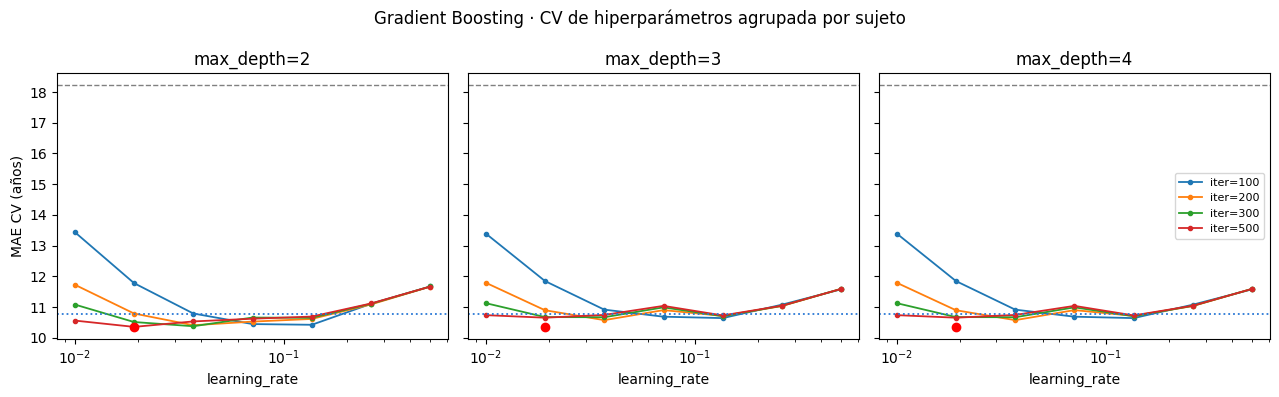

In [5]:
%matplotlib inline
# train.py fuerza matplotlib.use("Agg") al importarse (para loguear a mlflow sin display);
# se reactiva aquí el backend inline para que el notebook muestre la figura.
fig, axes = plt.subplots(1, len(MAX_DEPTHS), figsize=(4.3 * len(MAX_DEPTHS), 4), sharey=True)
for ax, depth in zip(axes, MAX_DEPTHS):
    sub = grid[grid.max_depth == depth]
    for max_iter in MAX_ITERS:
        s = sub[sub.max_iter == max_iter].sort_values("learning_rate")
        ax.plot(s.learning_rate, s.mae_oof, "o-", lw=1.3, ms=3, label=f"iter={max_iter}")
    ax.axhline(naive_mae_dev, ls="--", c="gray", lw=1)
    ax.axhline(10.77, ls=":", c="#2a78d6", lw=1.3, label="Ridge (10.77)" if depth == MAX_DEPTHS[0] else None)
    ax.scatter([best.learning_rate], [best.mae_oof], color="red", zorder=5,
               label="mejor combinación" if depth == int(best.max_depth) else None)
    ax.set_xscale("log")
    ax.set_xlabel("learning_rate")
    ax.set_title(f"max_depth={depth}")
axes[0].set_ylabel("MAE CV (años)")
axes[-1].legend(fontsize=8)
fig.suptitle("Gradient Boosting · CV de hiperparámetros agrupada por sujeto")
fig.tight_layout()
plt.show()

## 5 · Evaluación en el conjunto de prueba (una sola vez)

Se reentrena la mejor combinación con los 62 sujetos de desarrollo y se
evalúa una única vez sobre los 16 de prueba, siguiendo la misma disciplina
que el resto de experimentos (esta cifra no se vuelve a consultar ni se usa
para reajustar hiperparámetros).

MAE test (una vez): 9.78 años · RMSE 12.92 · corr(BAI,edad) test -0.49
naive MAE test: 18.71


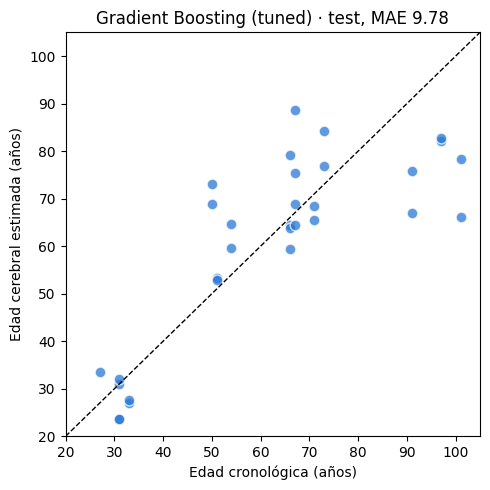

In [6]:
m_dev = gb_fn(int(best.max_depth), float(best.learning_rate), int(best.max_iter))()
m_dev.fit(X, y)
pred_test = m_dev.predict(X_test)

test_mae = mean_absolute_error(y_test, pred_test)
test_rmse = float(np.sqrt(mean_squared_error(y_test, pred_test)))
test_bai_corr = pearsonr(pred_test - y_test, y_test)[0]

print(f"MAE test (una vez): {test_mae:.2f} años · RMSE {test_rmse:.2f} · "
      f"corr(BAI,edad) test {test_bai_corr:+.2f}")
print(f"naive MAE test: {naive_mae_test:.2f}")

%matplotlib inline
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_test, pred_test, alpha=0.75, color="#2a78d6", edgecolor="white", s=60)
lims = [20, 105]
ax.plot(lims, lims, "k--", lw=1)
ax.set(xlim=lims, ylim=lims)
ax.set_xlabel("Edad cronológica (años)")
ax.set_ylabel("Edad cerebral estimada (años)")
ax.set_title(f"Gradient Boosting (tuned) · test, MAE {test_mae:.2f}")
fig.tight_layout()
plt.show()

## 6 · Resultado

| Modelo | MAE CV dev (defendible) | corr(BAI, edad) CV | MAE test (una vez) |
|---|---:|---:|---:|
| Naive (edad media) | 18,23 | — | 18,71 |
| Ridge (línea base, alpha=10) | 10,77 | −0,49 | 11,52 |
| Gradient Boosting (config. fija, sin tuning) | 10,81 | −0,57 | 9,81 |
| **Gradient Boosting (tuned, esta corrida)** | **10,35** | −0,61 | 9,78 |

Con un barrido real de hiperparámetros (`max_depth=2`, `learning_rate≈0,019`,
`max_iter=500`: árboles poco profundos, tasa de aprendizaje baja, muchas
iteraciones), Gradient Boosting sí supera a Ridge en la métrica defendible de
CV, por unos 0,4 años de MAE. La combinación ganadora usa regularización
fuerte (árboles superficiales, aprendizaje lento), consistente con lo
esperado en una muestra de apenas 62 sujetos de desarrollo: darle al modelo
más flexibilidad (`max_depth` mayor, `learning_rate` alto) empeora la CV en
casi todos los casos de la rejilla.

**El costo es el sesgo.** La corrección de la regresión a la media empeora
según se ajustan mejor los hiperparámetros: `corr(BAI, edad)` pasa de −0,49
en Ridge a −0,57 en la config. fija de Gradient Boosting y a −0,61 en la
versión afinada. Es decir, el modelo que mejor predice la edad en promedio es
también el que produce un índice BAI más sesgado hacia la media, el mismo
patrón de trade-off que se documentó para la variante Ridge V2 con corrección
explícita del sesgo. Gradient Boosting, tal como está aquí, no incorpora esa
corrección.

**Conclusión.** Gradient Boosting sí tiene potencial por encima de Ridge en
la cifra que el proyecto usa para decidir (CV MAE), pero no es una mejora sin
matices: gana ~0,4 años de MAE a cambio de un BAI más sesgado, y el mejor
punto de la rejilla favorece bastante regularización, señal de que con más
sujetos el margen podría ampliarse. Antes de promoverlo sobre Ridge como
modelo de producción habría que decidir en equipo si ese trade-off es
aceptable, o aplicarle a Gradient Boosting una corrección de sesgo análoga a
la de Ridge V2.